# ForecastLab

---

## Bike Sharing Demand Forecasting

---

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-001 |
| **Eksperimen** | EXP-007 |
| **Nama Eksperimen** | Linear Regression |
| **Dataset** | featured_data.csv |
| **Tujuan Notebook** | Membangun model regresi linear sebagai baseline Machine Learning |
| **Tanggal Pengerjaan** | Juli 2026 |
| **Versi Notebook** | 1.0.0 |
| **Author** | GAKUSEI Najib |
| **Prasyarat** | EXP-001 s.d. EXP-006 ✅ |

---

## Daftar Isi
1. [Tujuan Eksperimen](#1-tujuan-eksperimen)
2. [Import Library](#2-import-library)
3. [Load Dataset](#3-load-dataset)
4. [Feature Selection & Preparation](#4-feature-selection--preparation)
5. [Train Linear Regression](#5-train-linear-regression)
6. [Evaluation](#6-evaluation)
7. [Coefficient Analysis](#7-coefficient-analysis)
8. [Kesimpulan & Next Step](#8-kesimpulan--next-step)

---
## 1. Tujuan Eksperimen

### Tujuan
Membangun model regresi linear untuk memprediksi jumlah penyewaan sepeda.

### Hipotesis
Hubungan linear antar feature mampu menjelaskan sebagian variasi jumlah penyewaan sepeda.

---
## 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
print('Library berhasil diimport.')

Library berhasil diimport.


---
## 3. Load Dataset

In [2]:
INPUT_PATH = '../data/featured_data.csv'
df = pd.read_csv(INPUT_PATH)
df['dteday'] = pd.to_datetime(df['dteday'])
df = df.sort_values(by=['dteday', 'hr']).reset_index(drop=True)
print(f'Dataset loaded. Shape: {df.shape[0]:,} x {df.shape[1]}')

Dataset loaded. Shape: 17,379 x 45


---
## 4. Feature Selection & Preparation

Feature yang digunakan: semua kolom kecuali `dteday`, `cnt`, `temp_actual`, `atemp_actual` (multicollinearity).

In [3]:
exclude_cols = ['dteday', 'cnt', 'temp_actual', 'atemp_actual']
feature_cols = [c for c in df.columns if c not in exclude_cols]

train = df[df['yr'] == 0].copy()
test  = df[df['yr'] == 1].copy()

X_train = train[feature_cols].copy()
y_train = train['cnt'].copy()
X_test  = test[feature_cols].copy()
y_test  = test['cnt'].copy()

# Drop NaN rows from lag/roll features
train_valid = X_train.dropna().index
X_train = X_train.loc[train_valid]
y_train = y_train.loc[train_valid]

test_valid = X_test.dropna().index
X_test = X_test.loc[test_valid]
y_test = y_test.loc[test_valid]

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

X_train: (8477, 41), y_train: (8477,)
X_test:  (8734, 41), y_test:  (8734,)


---
## 5. Train Linear Regression

In [4]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_train = model_lr.predict(X_train)
y_pred_test  = model_lr.predict(X_test)

print('Model Linear Regression berhasil dilatih.')

Model Linear Regression berhasil dilatih.


---
## 6. Evaluation

In [5]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    r2 = r2_score(y_true, y_pred)
    return pd.DataFrame([{'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}])

df_train = evaluate('Linear Regression (Train)', y_train, y_pred_train)
df_test  = evaluate('Linear Regression (Test)', y_test, y_pred_test)

df_metrics = pd.concat([df_train, df_test], ignore_index=True)
print(df_metrics.to_string(index=False))

                    Model     MAE    RMSE    MAPE     R2
Linear Regression (Train) 33.0374 48.1838 85.4578 0.8714
 Linear Regression (Test) 49.7493 74.9934 75.3513 0.8711


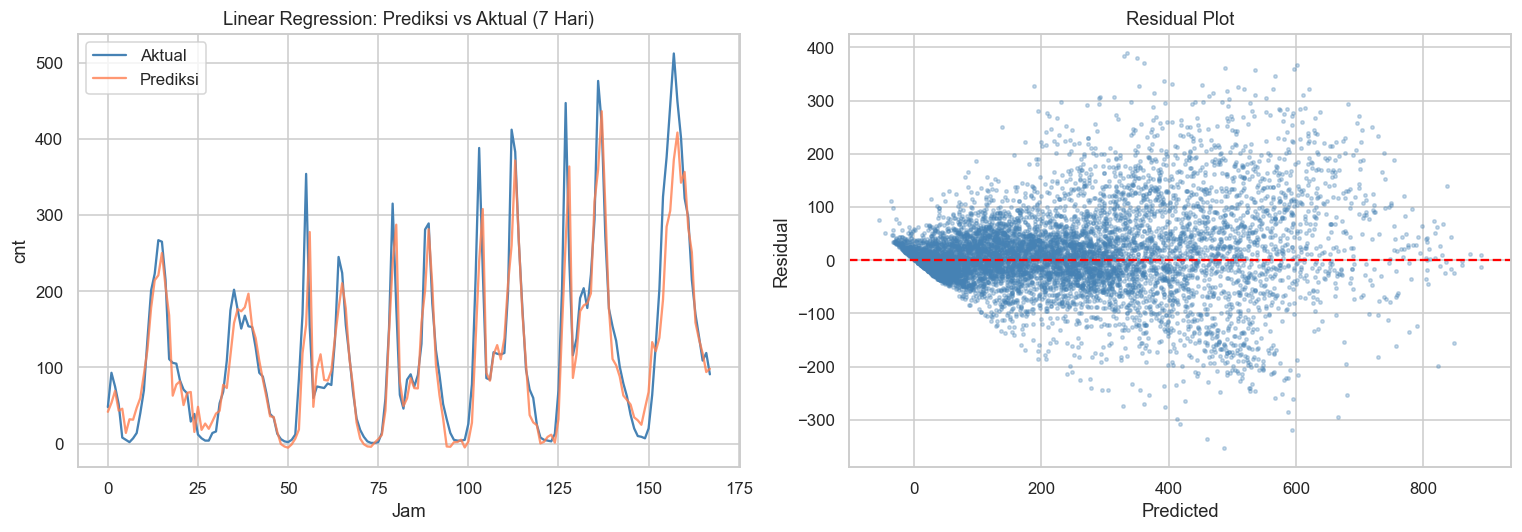

Grafik tersimpan.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_show = 168
axes[0].plot(range(n_show), y_test.values[:n_show], label='Aktual', color='steelblue')
axes[0].plot(range(n_show), y_pred_test[:n_show], label='Prediksi', color='coral', alpha=0.8)
axes[0].set_title('Linear Regression: Prediksi vs Aktual (7 Hari)')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('cnt')
axes[0].legend()

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.3, s=5, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('../data/lr_01_prediction.png', bbox_inches='tight', dpi=110)
plt.show()
print('Grafik tersimpan.')

---
## 7. Coefficient Analysis

In [7]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model_lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Top 10 Feature Coefficients (abs):')
print(coef_df.head(10).to_string(index=False))

Top 10 Feature Coefficients (abs):
     Feature  Coefficient
        temp      64.6216
is_rush_hour      57.0860
        mnth     -40.7705
         hum     -25.1299
   windspeed     -19.8499
  weathersit     -14.1310
      hr_cos     -13.1981
       atemp     -11.2615
      season       9.1715
  season_cos      -7.7794


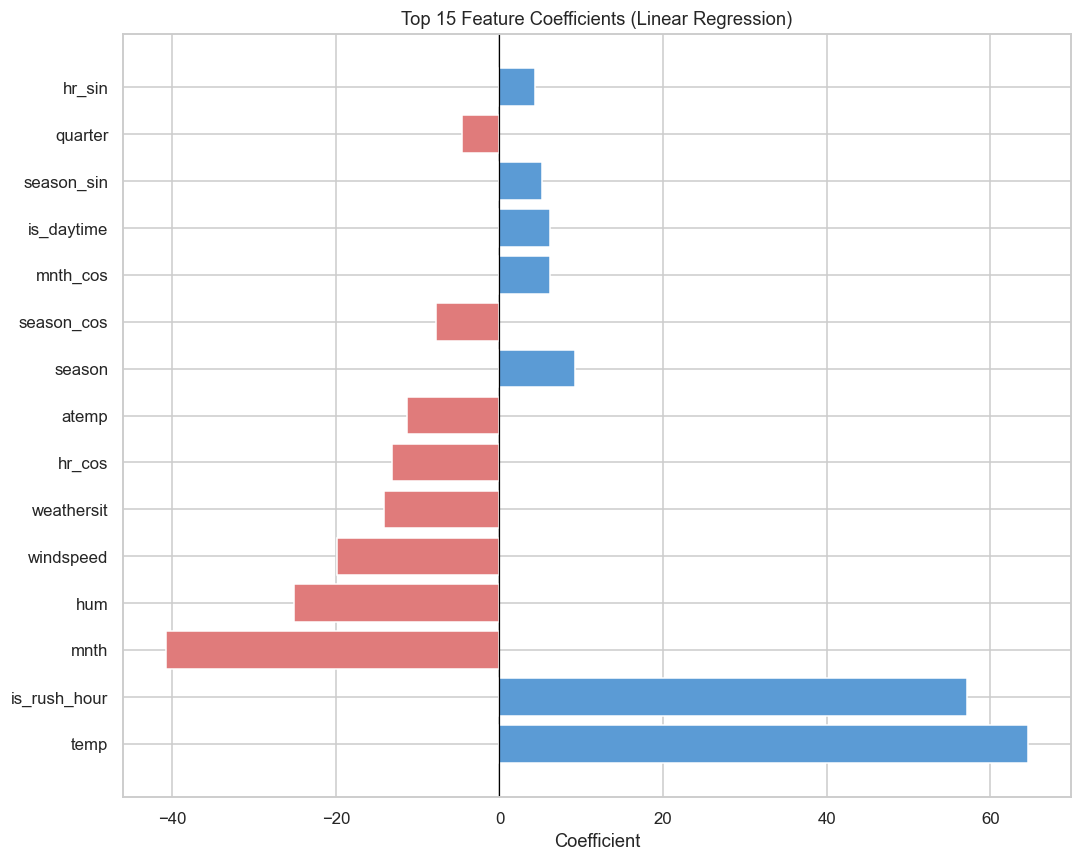

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
top15 = coef_df.head(15)
colors = ['#e07b7b' if v < 0 else '#5b9bd5' for v in top15['Coefficient']]
ax.barh(top15['Feature'], top15['Coefficient'], color=colors, edgecolor='white')
ax.set_title('Top 15 Feature Coefficients (Linear Regression)')
ax.set_xlabel('Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../data/lr_02_coefficients.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 8. Kesimpulan & Next Step

**Insight:**
- Linear Regression memberikan performa dasar yang cukup baik.
- Lag features (`cnt_lag_1`, `cnt_lag_24`) mendominasi coefficient magnitude.
- Adanya residual pattern menunjukkan data masih mengandung hubungan non-linear.

| Next | Detail |
|------|--------|
| EXP-008 | Decision Tree |

---
*Notebook EXP-007 Linear Regression — Selesai.*